# Objectif 

Date de création : 18/05/2026
Illustration de la méthode de filtrage dans le plan (f, k) sur la séquence 144. 

In [39]:
# %matplotlib ipympl

import os
import sys
import numpy as np
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks


sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# from misc import mult_along_axis
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.simu.sensi_simu_utils import (
    run_full_study,
    compute_rtf_dataset,
    plot_intensity,
    plot_tl_pi_frequency_range_plan,
    get_dist
)

# from propa.rtf.rtf_utils import D_hermitian_angle_fast
import source.global_constants as g
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    SmallFigure,
    color,
    set_subfigures_abc_labels,
)


from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import *

In [40]:
fig_folder = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\reseau_9R\img"
)

## Chargement des données 

In [41]:
# Select frequency range
fmin = 0
fmax = 100

In [42]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\reseau_9R\data\library\library_0.nc"
ds_lib = xr.open_dataset(fpath)
ds_lib

<xarray.Dataset> Size: 2MB
Dimensions:       (h_index: 5, f_rtf: 513, replica_id: 78)
Coordinates:
  * h_index       (h_index) int64 40B 1 2 3 5 6
  * f_rtf         (f_rtf) float32 2kB 0.0 0.09766 0.1953 ... 49.8 49.9 50.0
  * replica_id    (replica_id) int64 624B 0 1 2 3 4 5 6 ... 71 72 73 74 75 76 77
Data variables:
    rtf_amp       (h_index, f_rtf, replica_id) float32 800kB ...
    rtf_phase     (h_index, f_rtf, replica_id) float32 800kB ...
    feature_psd   (f_rtf, replica_id) float32 160kB ...
    replica_type  (replica_id) int64 624B ...
Attributes:
    reference_receiver_id:  1
    rtf_estimator:          cs-evd
    description:            Library dataset containing RTF-MFP features.
    type:                   library
    id:                     0

In [43]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\reseau_9R\data\sequences\passive\sequence_passive_2023-01-02_17-00-00_to_2023-01-02_19-00-00_rtf.nc"
ds_sig = xr.open_dataset(fpath)
ds_sig

<xarray.Dataset> Size: 135MB
Dimensions:        (h_index: 5, time: 720000, f_rtf: 513, segment_dt: 956,
                    f_csdm: 513, h_index_bis: 5)
Coordinates:
  * h_index        (h_index) int64 40B 1 5 12 24 35
  * time           (time) float32 3MB 0.0 0.01 0.02 ... 7.2e+03 7.2e+03 7.2e+03
  * f_rtf          (f_rtf) float32 2kB 0.0 0.09766 0.1953 ... 49.8 49.9 50.0
  * segment_dt     (segment_dt) datetime64[ns] 8kB 2023-01-02T17:00:07.500000...
  * f_csdm         (f_csdm) float32 2kB 0.0 0.09766 0.1953 ... 49.8 49.9 50.0
  * h_index_bis    (h_index_bis) int64 40B 1 5 12 24 35
Data variables:
    signal         (h_index, time) float32 14MB ...
    start_dt       datetime64[ns] 8B ...
    end_dt         datetime64[ns] 8B ...
    rtf_amp_hat    (h_index, f_rtf, segment_dt) float32 10MB ...
    rtf_phase_hat  (h_index, f_rtf, segment_dt) float32 10MB ...
    Rx             (f_csdm, h_index, h_index_bis, segment_dt) float32 49MB ...
    Rv             (f_csdm, h_index, h_index_bis, segment_dt) float32 49MB ...
Attributes:
    fs:                              100
    ts:                              0.01
    datetime_format:                 %Y-%m-%d_%H-%M-%S
    record_id:                       passive_2023-01-02_17-00-00_to_2023-01-0...
    root_img:                        C:\Users\baptiste.menetrier\Desktop\devP...
    root_data:                       C:\Users\baptiste.menetrier\Desktop\devP...
    h_index_ref:                     1
    analysis_segment_duration:       30
    analysis_segment_alpha_overlap:  0.75

### Données des OBS 

In [44]:
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\reseau_9R\data\channel_EDH_wav.nc"
)

ds_wav = ds_wav.sel(
    receiver_id=[
        "RCV16",
        "RCV18",
        "RCV21",
    ]
)


In [45]:
ds_wav

<xarray.Dataset> Size: 202MB
Dimensions:          (time_RCV01: 1440000, time_RCV02: 1440000,
                      time_RCV03: 1440000, time_RCV05: 1440000,
                      time_RCV06: 1440000, time_RCV07: 1440000,
                      time_RCV08: 1440000, time_RCV09: 1440000,
                      time_RCV10: 1440000, time_RCV11: 1440000,
                      time_RCV12: 1440000, time_RCV13: 1440000,
                      ...
                      time_RCV26: 1440000, time_RCV28: 1440000,
                      time_RCV29: 1440000, time_RCV30: 1440000,
                      time_RCV31: 1440000, time_RCV33: 1440000,
                      time_RCV34: 1440000, time_RCV35: 1440000,
                      time_RCV37: 1440000, time_RCV38: 1440000,
                      time_RCV39: 1440000, receiver_id: 3)
Coordinates:
  * receiver_id      (receiver_id) <U5 60B 'RCV16' 'RCV18' 'RCV21'
Dimensions without coordinates: time_RCV01, time_RCV02, time_RCV03, time_RCV05,
                                time_RCV06, time_RCV07, time_RCV08, time_RCV09,
                                time_RCV10, time_RCV11, time_RCV12, time_RCV13,
                                time_RCV14, time_RCV15, time_RCV16, time_RCV17,
                                time_RCV18, time_RCV19, time_RCV20, time_RCV21,
                                time_RCV22, time_RCV23, time_RCV24, time_RCV25,
                                time_RCV26, time_RCV28, time_RCV29, time_RCV30,
                                time_RCV31, time_RCV33, time_RCV34, time_RCV35,
                                time_RCV37, time_RCV38, time_RCV39
Data variables: (12/37)
    signal_RCV01     (time_RCV01) float32 6MB ...
    signal_RCV02     (time_RCV02) float32 6MB ...
    signal_RCV03     (time_RCV03) float32 6MB ...
    signal_RCV05     (time_RCV05) float32 6MB ...
    signal_RCV06     (time_RCV06) float32 6MB ...
    signal_RCV07     (time_RCV07) float32 6MB ...
    ...               ...
    signal_RCV35     (time_RCV35) float32 6MB ...
    signal_RCV37     (time_RCV37) float32 6MB ...
    signal_RCV38     (time_RCV38) float32 6MB ...
    signal_RCV39     (time_RCV39) float32 6MB ...
    start_datetimes  (receiver_id) datetime64[ns] 24B ...
    end_datetimes    (receiver_id) datetime64[ns] 24B ...
Attributes:
    description:      Merged wav files.
    channel:          EDH
    fs:               100
    datetime_format:  %Y-%m-%d_%H-%M-%S

2048


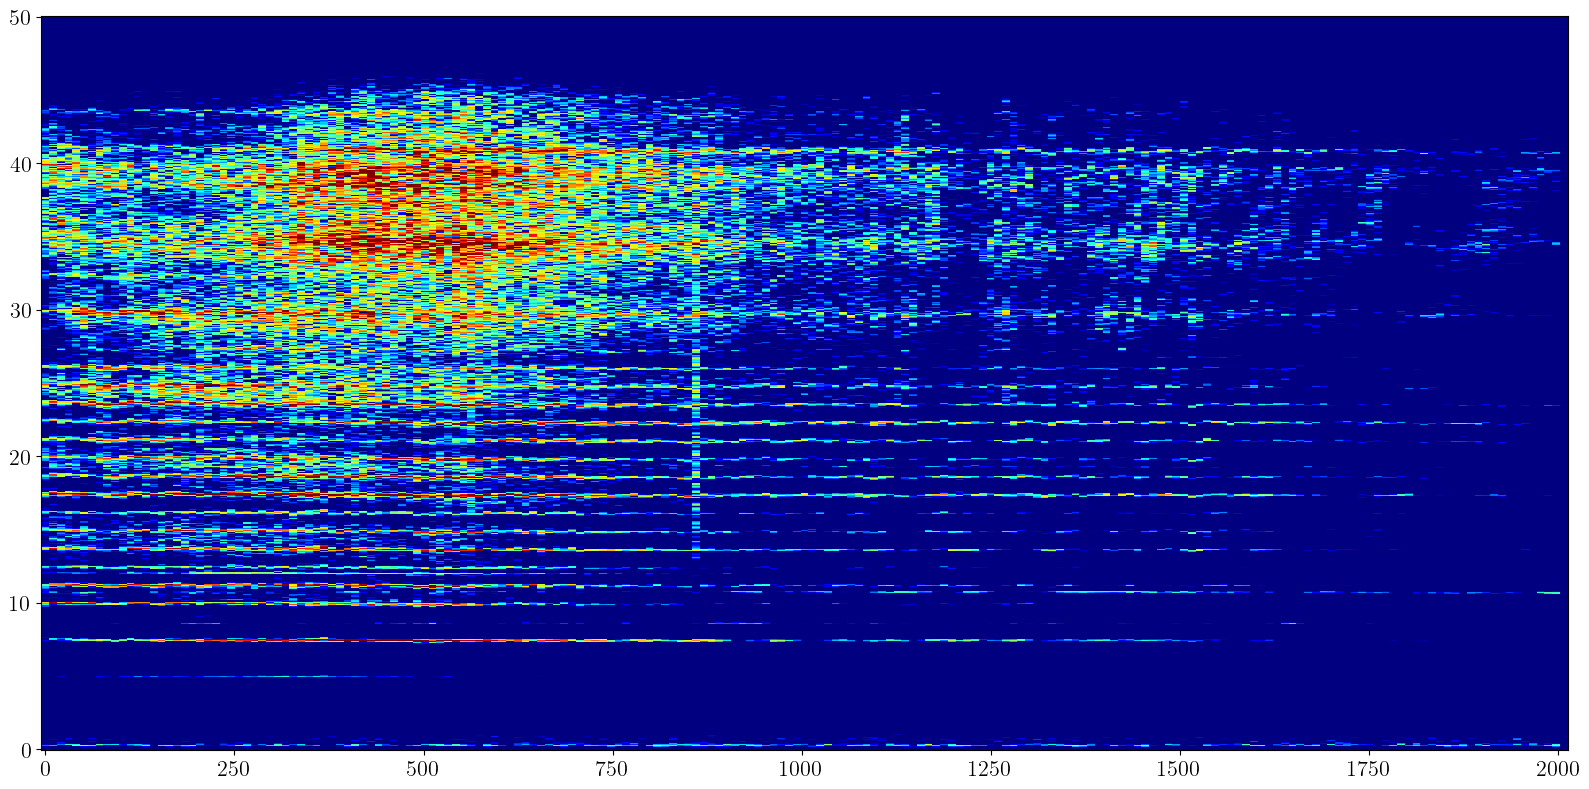

In [57]:
nperseg=2**11
noverlap=2**10
print(nperseg)

fs = ds_wav.fs
ts = 1 /fs 
sig = ds_wav.signal_RCV18
sig = sig.isel(time_RCV18=slice(int(7000 / ts), int(9000 / ts)))

# print(sig)
f, t, Sxx = sp.stft(
    sig,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    # nfft=nfft,
    scaling="psd",
)
Sxx_db = 20 * np.log10(abs(Sxx))

plt.figure()
plt.pcolormesh(
    t,
    f,
    20 * np.log10(abs(Sxx)),
    cmap="jet",
    vmin=np.percentile(Sxx_db, 70),
    vmax=np.percentile(Sxx_db, 99.5),
)

# plt.xlim(5000, 9000)

In [47]:
f.shape


(4097,)

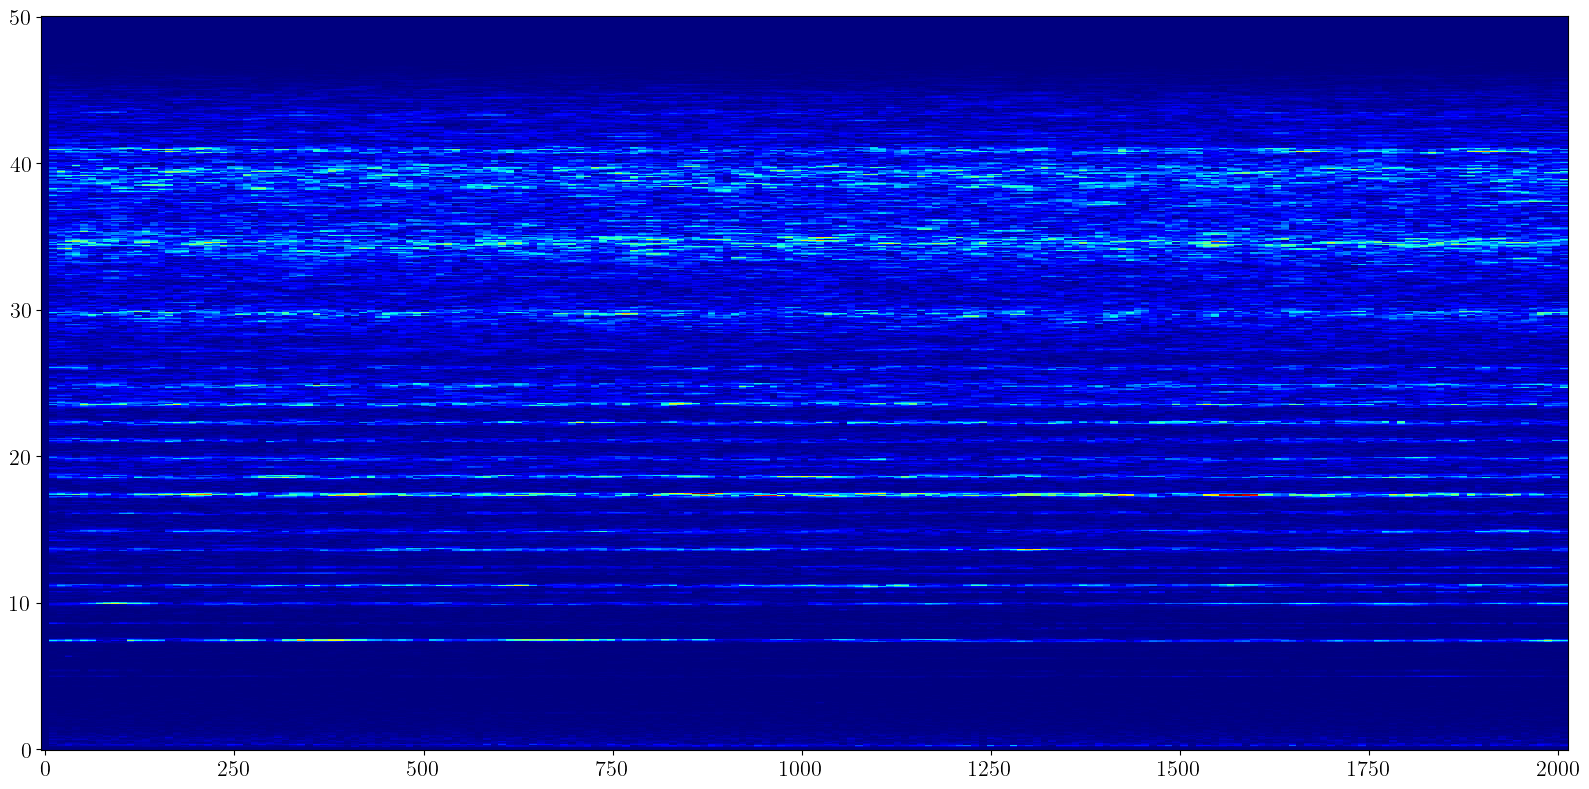

In [58]:
Sxx_fk = Sxx - np.mean(Sxx, axis=1, keepdims=True)
fk = np.fft.fft(Sxx_fk, axis=1)

plt.figure()
plt.pcolormesh(t, f, np.abs(fk), cmap="jet")

In [49]:
# plot_sequence_spectrogram(
#     ds_sig,
#     ds_wav,
#     fig_folder,
#     nperseg=2**12,
#     noverlap=2**11,
#     fmin=fmin,
#     fmax=fmax,
#     fname="sequence_signal_spectrogram.png",
# )

## Variations du module de $\Pi$ dans le plan (f, pos)


On s'intéresse aux variations de $\lvert \Pi \rvert$ dans le plan (f, numéro de réplique).

In [50]:
ds_sig

<xarray.Dataset> Size: 135MB
Dimensions:        (h_index: 5, time: 720000, f_rtf: 513, segment_dt: 956,
                    f_csdm: 513, h_index_bis: 5)
Coordinates:
  * h_index        (h_index) int64 40B 1 5 12 24 35
  * time           (time) float32 3MB 0.0 0.01 0.02 ... 7.2e+03 7.2e+03 7.2e+03
  * f_rtf          (f_rtf) float32 2kB 0.0 0.09766 0.1953 ... 49.8 49.9 50.0
  * segment_dt     (segment_dt) datetime64[ns] 8kB 2023-01-02T17:00:07.500000...
  * f_csdm         (f_csdm) float32 2kB 0.0 0.09766 0.1953 ... 49.8 49.9 50.0
  * h_index_bis    (h_index_bis) int64 40B 1 5 12 24 35
Data variables:
    signal         (h_index, time) float32 14MB ...
    start_dt       datetime64[ns] 8B ...
    end_dt         datetime64[ns] 8B ...
    rtf_amp_hat    (h_index, f_rtf, segment_dt) float32 10MB ...
    rtf_phase_hat  (h_index, f_rtf, segment_dt) float32 10MB ...
    Rx             (f_csdm, h_index, h_index_bis, segment_dt) float32 49MB ...
    Rv             (f_csdm, h_index, h_index_bis, segment_dt) float32 49MB ...
Attributes:
    fs:                              100
    ts:                              0.01
    datetime_format:                 %Y-%m-%d_%H-%M-%S
    record_id:                       passive_2023-01-02_17-00-00_to_2023-01-0...
    root_img:                        C:\Users\baptiste.menetrier\Desktop\devP...
    root_data:                       C:\Users\baptiste.menetrier\Desktop\devP...
    h_index_ref:                     1
    analysis_segment_duration:       30
    analysis_segment_alpha_overlap:  0.75

Text(0.02, 0.5, 'Replica ID')

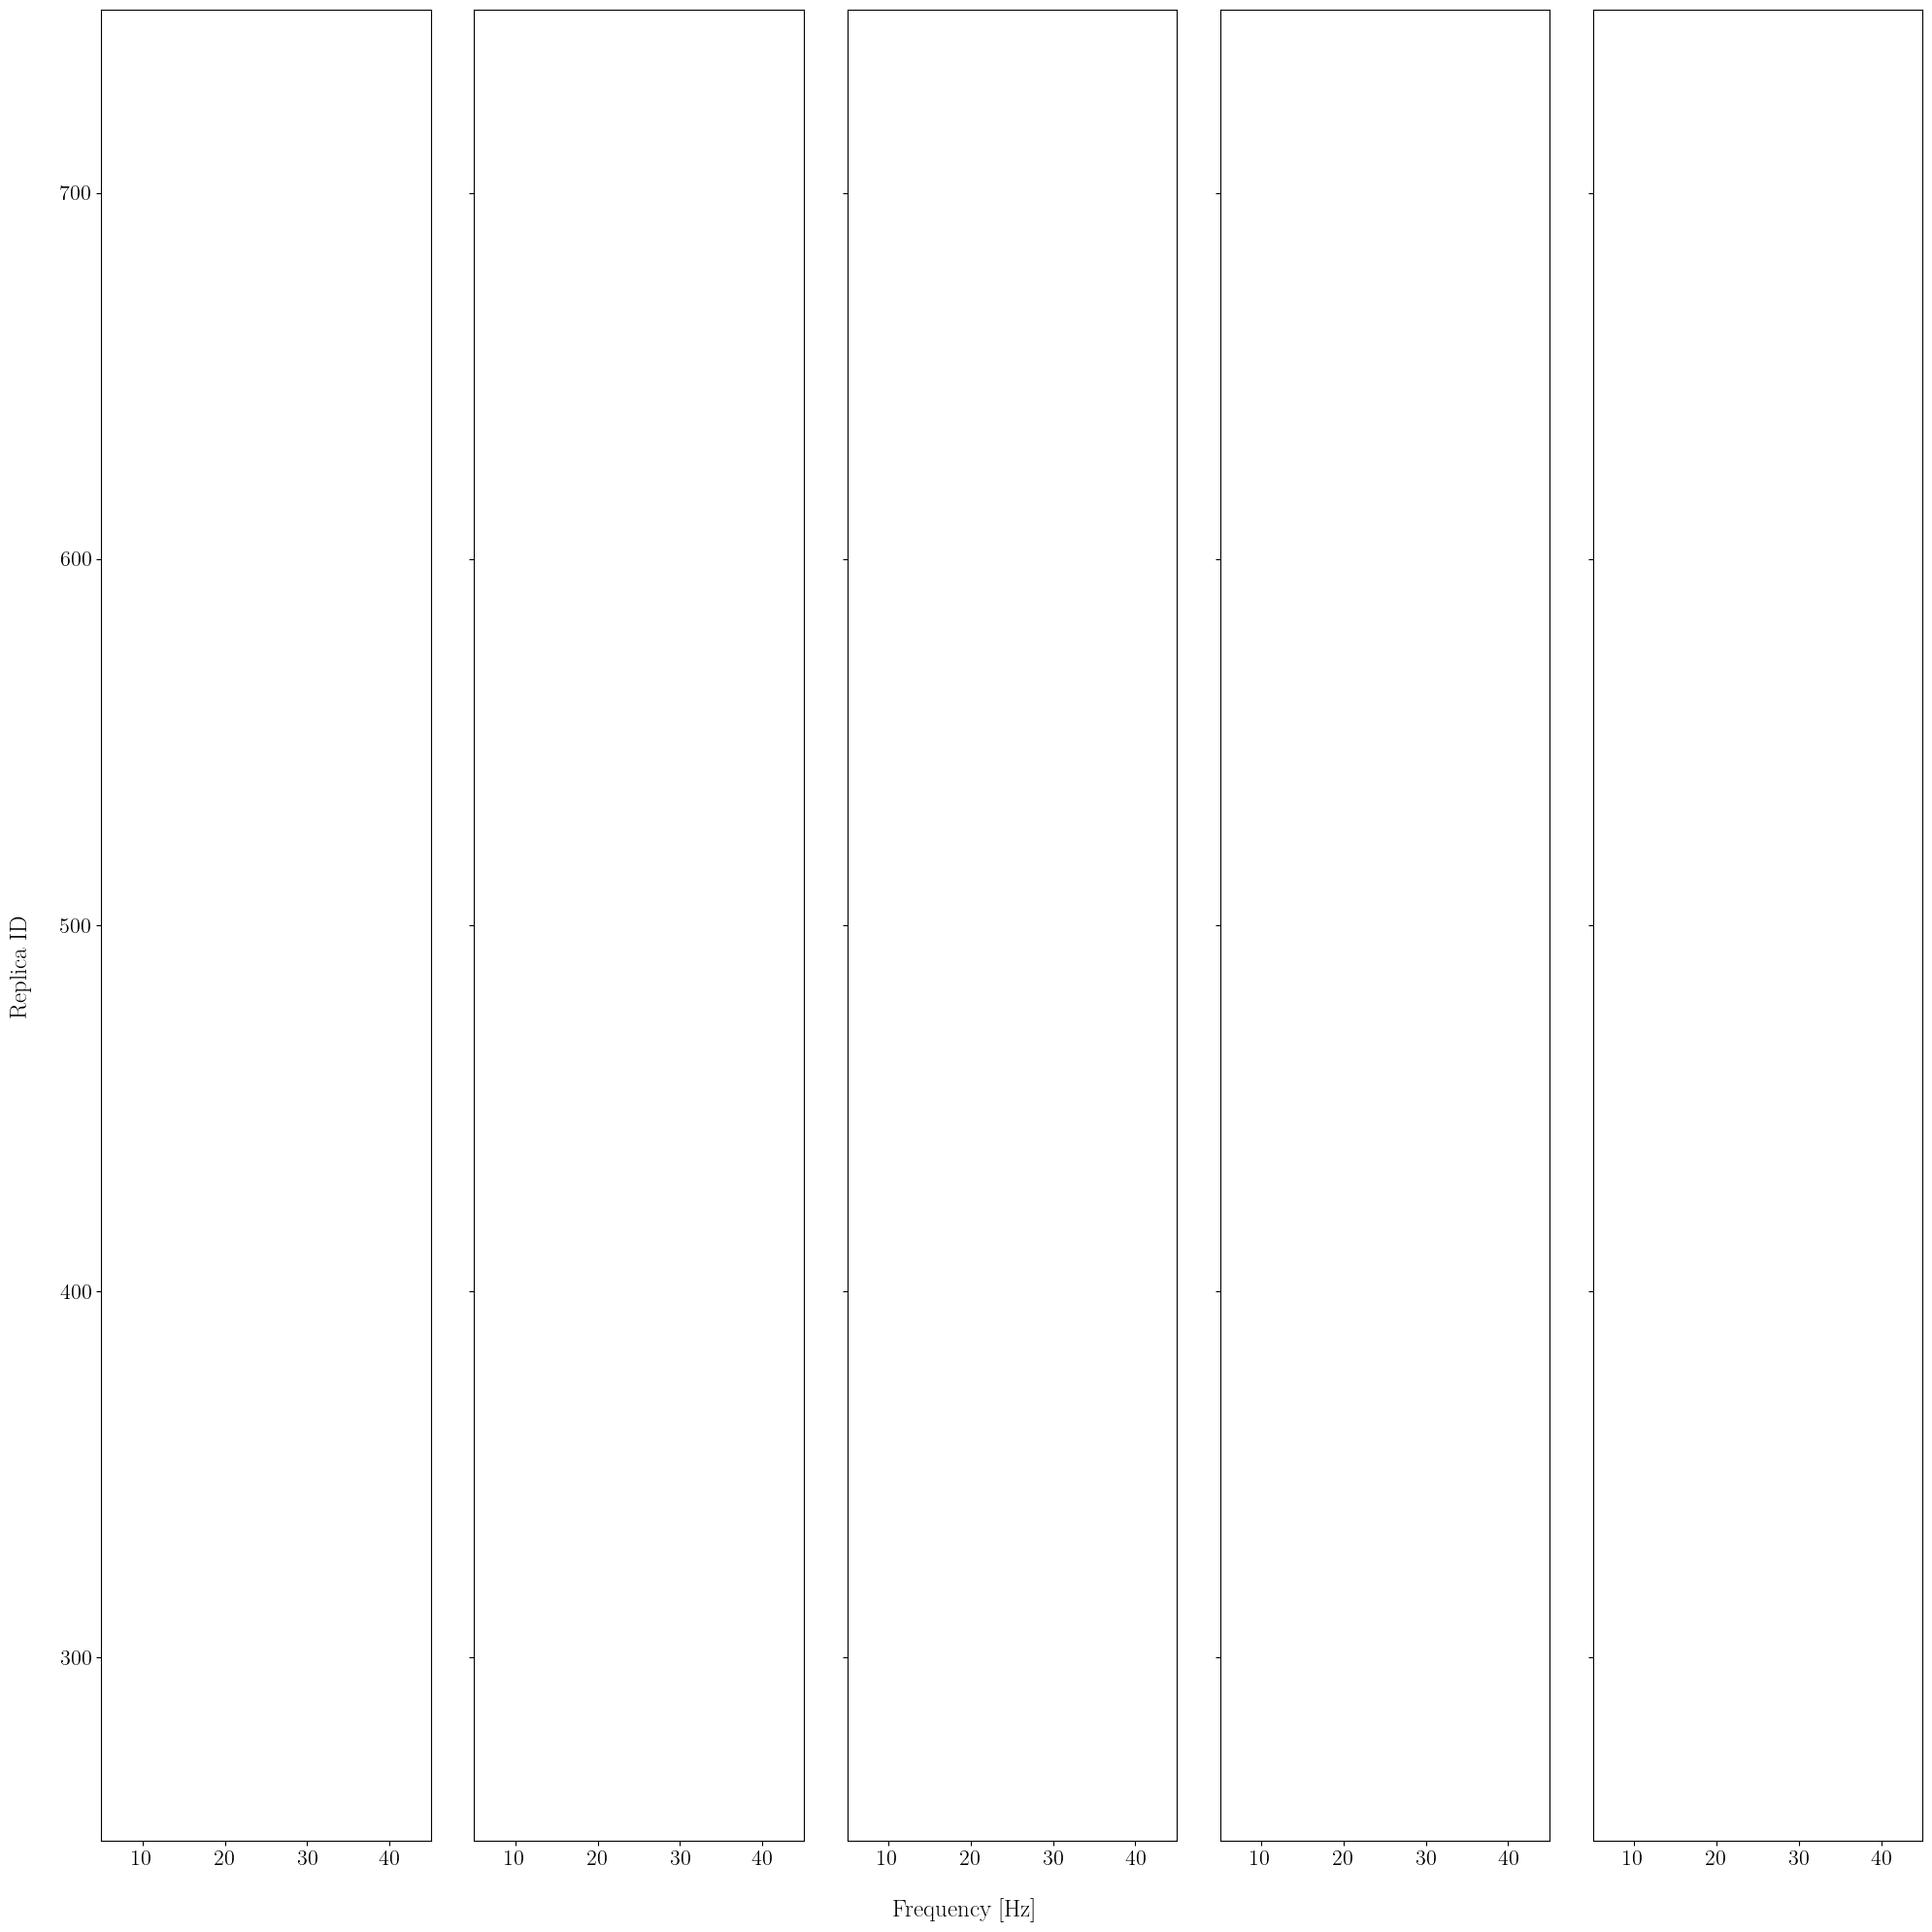

In [51]:
ds = ds_lib
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

ncol = 5
nrow = (
    len(idx_rcv_plot) // 4 + 1 if len(idx_rcv_plot) % 4 != 0 else len(idx_rcv_plot) // 4
)

fig, axs = plt.subplots(
    nrows=nrow, ncols=ncol, sharex=True, sharey="row", figsize=(20, 20)
)
ax_mod = axs.flatten()

rtf_cs_evd_amp = ds.rtf_amp
# Select frequency range
rtf_cs_evd_amp = rtf_cs_evd_amp.sel(f_rtf=slice(fmin, fmax))

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_amp_rcv = rtf_cs_evd_amp.sel(h_index=id_rcv)
    gamma = 20 * np.log10(rtf_cs_evd_amp_rcv)
    gamma.plot(
        x="f_rtf",
        cmap="magma",
        ax=ax_mod[i_ax],
        vmin=np.percentile(gamma, 5),
        vmax=np.percentile(gamma, 95),
        # cbar_kwargs={"label": r"$\gamma(f, r)$"},
        add_colorbar=False,
    )

    # for i_rcv in range(dist_rcv.shape[0]):
    #     if (reps[obs_cpa_idx[i_rcv]] <= replica_id_slice.stop) and (
    #         reps[obs_cpa_idx[i_rcv]] >= replica_id_slice.start
    #     ):
    #         ax_mod[i_ax].axhline(
    #             reps[obs_cpa_idx[i_rcv]],
    #             color=color(2 + i_rcv),
    #             label=f"CPA OBS{i_rcv+1}",
    #             linestyle="--",
    #             zorder=10,
    #         )

    # ax_mod[i_ax].set_title(f"OBS {id_rcv}")
    ax_mod[i_ax].set_title("")
    ax_mod[i_ax].set_xlabel("")
    ax_mod[i_ax].set_ylabel("")
    ax_mod[i_ax].set_ylim([250, 750])
    ax_mod[i_ax].set_xlim([5, 45])


    i_ax += 1

# set_subfigures_abc_labels(
#     axs=axs, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
# )
fig.supxlabel("Frequency [Hz]")
fig.supylabel("Replica ID")
# plt.ylim([8400, 8800])

Text(0.02, 0.5, 'Replica ID')

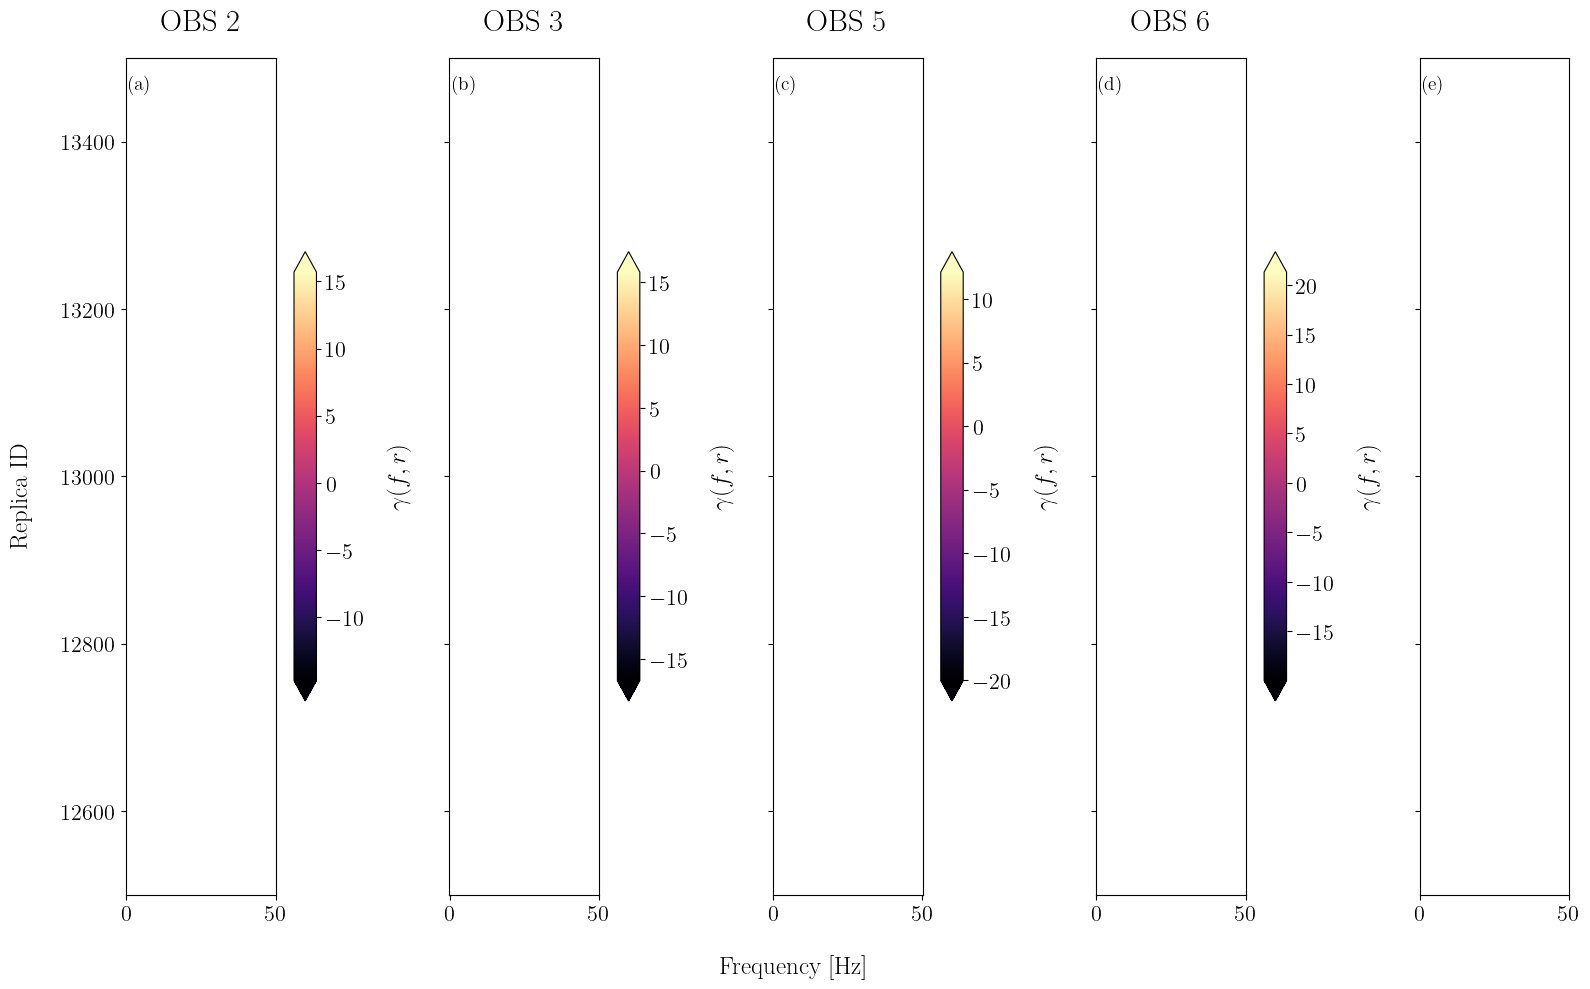

In [52]:
ds = ds_lib
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

ncol = 5
nrow = (
    len(idx_rcv_plot) // 4 + 1 if len(idx_rcv_plot) % 4 != 0 else len(idx_rcv_plot) // 4
)

fig, axs = plt.subplots(
    nrows=nrow, ncols=ncol, sharex=True, sharey="row", figsize=(16, 10)
)
ax_mod = axs.flatten()

rtf_cs_evd_amp = ds.rtf_amp
# Select frequency range
rtf_cs_evd_amp = rtf_cs_evd_amp.sel(f_rtf=slice(fmin, fmax))

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_amp_rcv = rtf_cs_evd_amp.sel(h_index=id_rcv)
    gamma = 20 * np.log10(rtf_cs_evd_amp_rcv)
    gamma.plot(
        x="f_rtf",
        cmap="magma",
        ax=ax_mod[i_ax],
        vmin=np.percentile(gamma, 5),
        vmax=np.percentile(gamma, 95),
        cbar_kwargs={"label": r"$\gamma(f, r)$"},
    )

    # for i_rcv in range(dist_rcv.shape[0]):
    #     if (reps[obs_cpa_idx[i_rcv]] <= replica_id_slice.stop) and (
    #         reps[obs_cpa_idx[i_rcv]] >= replica_id_slice.start
    #     ):
    #         ax_mod[i_ax].axhline(
    #             reps[obs_cpa_idx[i_rcv]],
    #             color=color(2 + i_rcv),
    #             label=f"CPA OBS{i_rcv+1}",
    #             linestyle="--",
    #             zorder=10,
    #         )

    ax_mod[i_ax].set_title(f"OBS {id_rcv}")
    ax_mod[i_ax].set_xlabel("")
    ax_mod[i_ax].set_ylabel("")
    ax_mod[i_ax].set_ylim([12500, 13500])

    i_ax += 1

set_subfigures_abc_labels(
    axs=axs, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
fig.supylabel("Replica ID")


Text(0.02, 0.5, 'Replica ID')

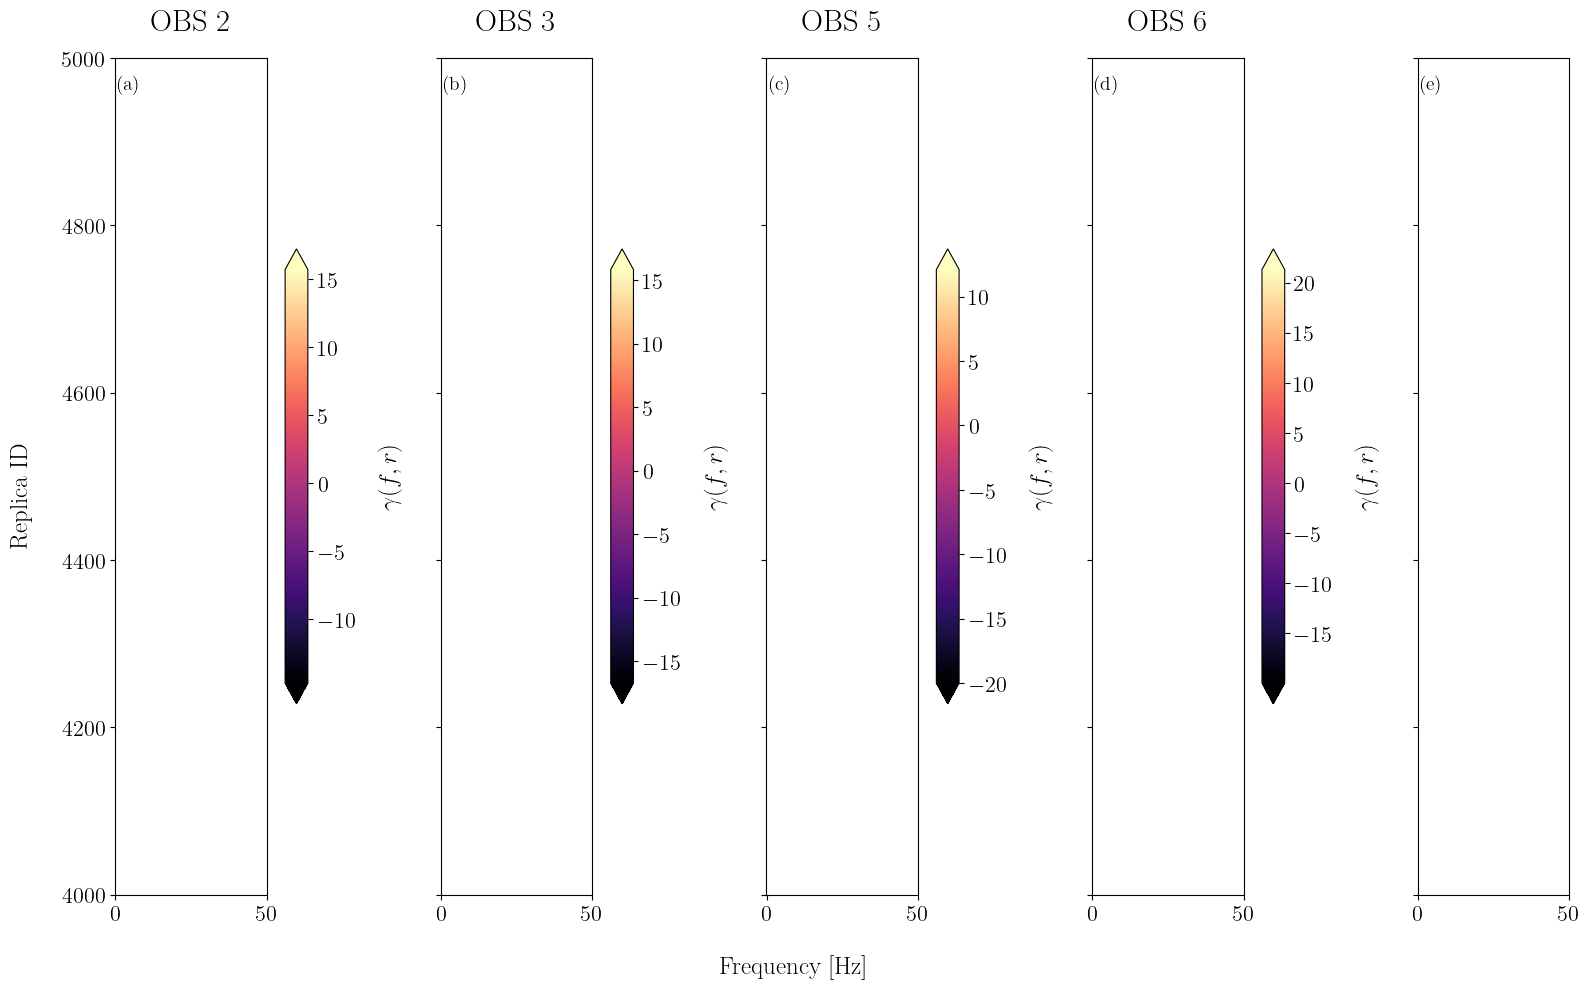

In [53]:
ds = ds_lib
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

ncol = 5
nrow = (
    len(idx_rcv_plot) // 4 + 1 if len(idx_rcv_plot) % 4 != 0 else len(idx_rcv_plot) // 4
)

fig, axs = plt.subplots(
    nrows=nrow, ncols=ncol, sharex=True, sharey="row", figsize=(16, 10)
)
ax_mod = axs.flatten()

rtf_cs_evd_amp = ds.rtf_amp
# Select frequency range
rtf_cs_evd_amp = rtf_cs_evd_amp.sel(f_rtf=slice(fmin, fmax))

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_amp_rcv = rtf_cs_evd_amp.sel(h_index=id_rcv)
    gamma = 20 * np.log10(rtf_cs_evd_amp_rcv)
    gamma.plot(
        x="f_rtf",
        cmap="magma",
        ax=ax_mod[i_ax],
        vmin=np.percentile(gamma, 5),
        vmax=np.percentile(gamma, 95),
        cbar_kwargs={"label": r"$\gamma(f, r)$"},
    )


    ax_mod[i_ax].set_title(f"OBS {id_rcv}")
    ax_mod[i_ax].set_xlabel("")
    ax_mod[i_ax].set_ylabel("")
    ax_mod[i_ax].set_ylim([4000, 5000])

    i_ax += 1

set_subfigures_abc_labels(
    axs=axs, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
fig.supylabel("Replica ID")
# plt.ylim([8400, 8800])

KeyError: "not all values found in index 'replica_id'. Try setting the `method` keyword argument (example: method='nearest')."

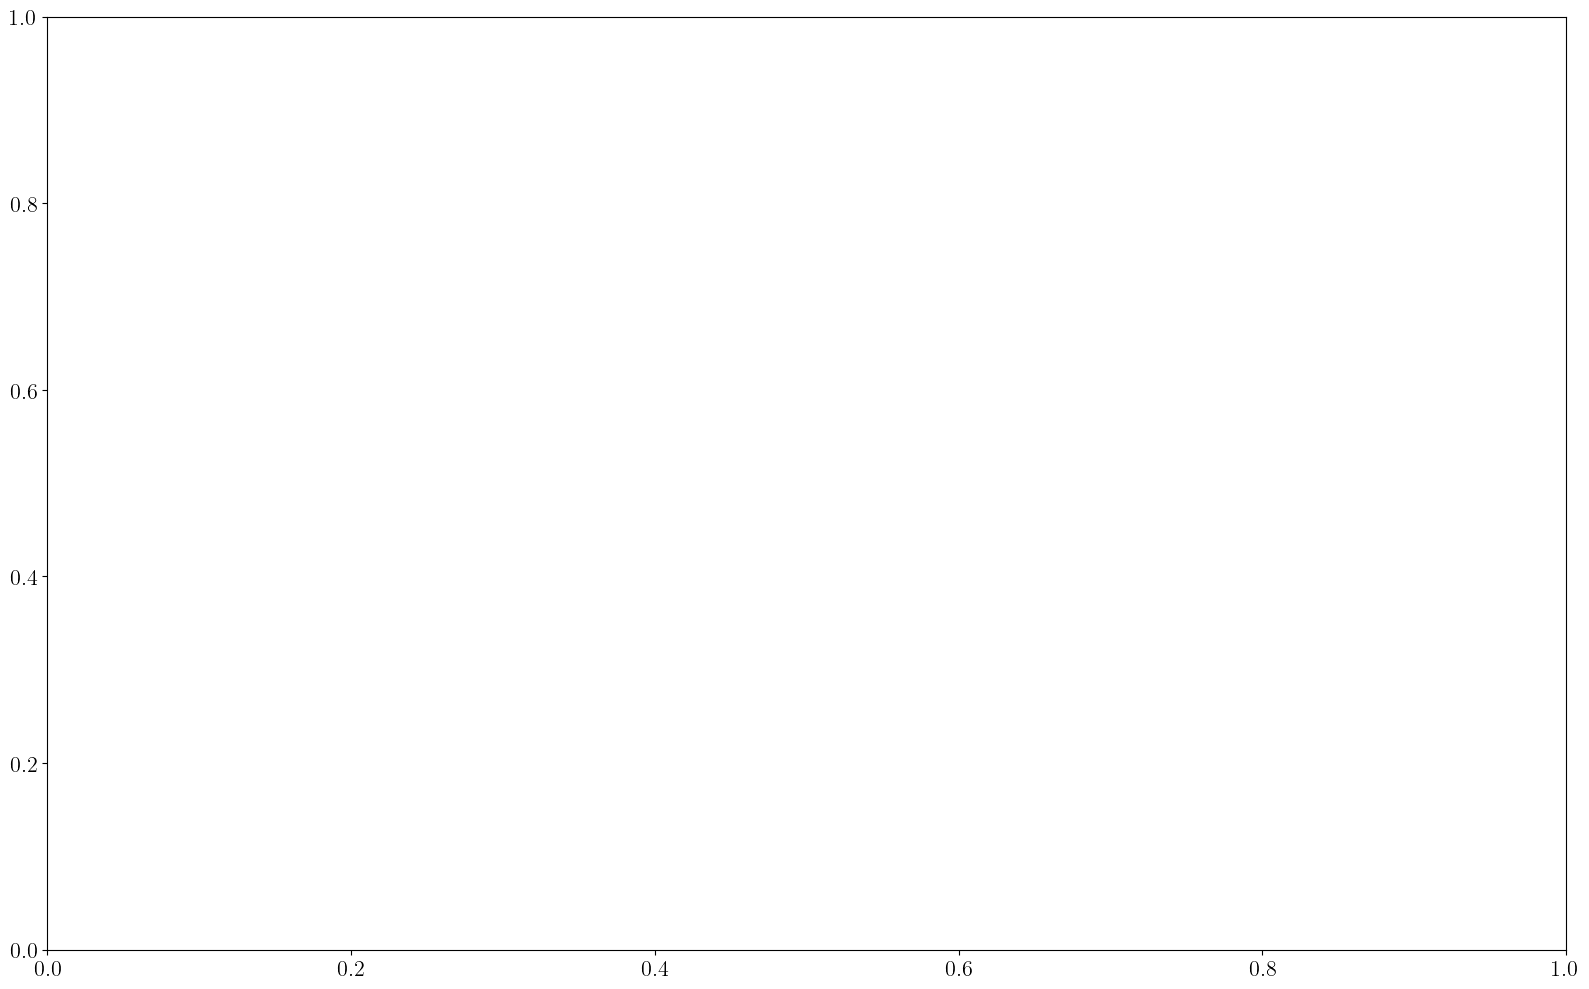

In [54]:
ds = ds_lib
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, axs = plt.subplots(
    nrows=1, ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)
ax_mod = axs

rtf_cs_evd_amp = ds.rtf_amp
# Select frequency range
rtf_cs_evd_amp = rtf_cs_evd_amp.sel(f_rtf=slice(fmin, fmax))

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_amp_rcv = rtf_cs_evd_amp.sel(h_index=id_rcv).sel(replica_id=8625)
    gamma = 20 * np.log10(rtf_cs_evd_amp_rcv)
    gamma.plot(
        # x="f_rtf",
        # cmap="magma",
        # ax=ax_mod[i_ax],
        # vmin=np.percentile(gamma, 5),
        # vmax=np.percentile(gamma, 95),
        # cbar_kwargs={"label": r"$\gamma(f, r)$"},
    )

    ax_mod.set_title(f"OBS {id_rcv}")
    ax_mod.set_xlabel("")
    ax_mod.set_ylabel("")

    i_ax += 1

set_subfigures_abc_labels(
    axs=axs, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
fig.supylabel("Replica ID")
plt.xlim([20, 40])

In [ ]:
# dist_rcv = get_dist_to_rcv(ds_lib)
# obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
# reps = ds_lib.replica_id.values

In [ ]:
# plot_gamma_along_sequence(
#     ds_sig,
#     dist_rcv,
#     obs_cpa_idx,
#     reps,
#     fig_folder,
#     replica_id_slice=slice(0, 500),
#     fmin=fmin,
#     fmax=fmax,
#     fname="rtf_mod_along_sequence.png",
# )